
# Tweety-02f — Le zoo modal : huit systèmes, une carte dont chaque trait est prouvé

> **Série Tweety — laboratoires croisés Java ↔ Lean (EPIC [#15066](https://github.com/jsboige/CoursIA/issues/15066), Tranche G, module [#17642](https://github.com/jsboige/CoursIA/pull/17642)).**
> Le sous-cube modal `FormalLogic.ModalZoo` du lake `formal_logic_lean` certifie **huit systèmes normaux**
> — K, KD, KT, KTB, K4, S4, KD45, S5 — et **l'ordre** qui les relie : onze arêtes de couverture et sept
> paires incomparables. Ce labo **lit ces listes dans le module lui-même**, en refait le calcul en Python,
> puis dessine la carte : chaque trait, et chaque absence de trait, a son théorème.

Navigation : [Tweety-3b-Modal-Lab-Lean](Tweety-3b-Modal-Lab-Lean.ipynb) (cadres et formules modales, côté exécution) ·
[Tweety-02e-Preuves-Hilbert-Gentzen-Lean](Tweety-02e-Preuves-Hilbert-Gentzen-Lean.ipynb) (calculs de preuve) ·
[Tweety-02d-FOL-Lab-Lean](Tweety-02d-FOL-Lab-Lean.ipynb) (labo FOL) ·
[README](README.md)

***

## Objectifs pédagogiques

1. **Exporter** les données certifiées du module (`ModalZoo.toJson`), exécutées par le noyau du lake épinglé — et non recopiées dans le carnet ;
2. **Lire les profils** des huit systèmes, et comprendre pourquoi le profil n'est pas la liste des axiomes : `KT` prouve `D`, `S5` prouve `B` et `4` ;
3. **Recalculer** l'ordre en Python à partir des seuls profils exportés, puis confronter ce calcul aux deux listes du module (onze arêtes, sept paires incomparables) ;
4. **Dessiner** le diagramme de Hasse, et distinguer les 28 paires du cube : 21 ordonnées, 7 incomparables ;
5. **Certifier** un trait (`strict_of_mem_covers`) et une **absence** de trait (`incomparable_of_mem`), puis mesurer avec `#print axioms` ce que ces preuves coûtent.

## Prérequis

- hôte Windows avec **WSL** et `elan` : les certificats Lean passent par WSL (règle F — on répare, on ne contourne pas) ;
- le lake [`formal_logic_lean`](../Lean/formal_logic_lean) construit (`lake exe cache get` puis `lake build FormalLogic.ModalZoo`) ;
- avoir parcouru [Tweety-02e](Tweety-02e-Preuves-Hilbert-Gentzen-Lean.ipynb) (ce qu'est un certificat) et, pour le versant modal exécuté, [Tweety-3b](Tweety-3b-Modal-Lab-Lean.ipynb).

### Durée estimée : 45 minutes

### Position dans la série

Les trois labos Lean de l'arc `02` (les logiques du corpus FFL) se partagent trois gestes :
[Tweety-02d](Tweety-02d-FOL-Lab-Lean.ipynb) certifie un **raisonnement**,
[Tweety-02e](Tweety-02e-Preuves-Hilbert-Gentzen-Lean.ipynb) certifie des **calculs de preuve**,
ce labo-ci certifie une **comparaison** — huit systèmes, et la carte de leurs forces relatives.



## 1. La question du labo

« Lequel est le plus fort ? » est la mauvaise question. Prenez `KTB` — réflexivité (`T`) et symétrie
(`B`) — et `S4` — réflexivité et transitivité (`4`). Aucun des deux ne contient l'autre : `KTB` ne
prouve pas `4`, `S4` ne prouve pas `B`. La relation « être plus faible que » n'est donc pas un ordre
total mais un **ordre partiel** — et c'est cette structure que le labo dessine.

Le module `FormalLogic.ModalZoo` (livré par la [#17642](https://github.com/jsboige/CoursIA/pull/17642))
traite **huit** systèmes normaux :

| Système | Générateurs (`gens`) | Profil (`profile`) |
|---|---|---|
| `K` | — | — |
| `KD` | `D` | `D` |
| `KT` | `T` | `D`, `T` |
| `KTB` | `T`, `B` | `D`, `T`, `B` |
| `K4` | `4` | `4` |
| `S4` | `T`, `4` | `D`, `T`, `4` |
| `KD45` | `D`, `4`, `5` | `D`, `4`, `5` |
| `S5` | `T`, `5` | `D`, `T`, `B`, `4`, `5` |

Deux colonnes, et déjà l'essentiel : le **profil** n'est pas la liste des générateurs. `KT` prouve `D`
(une relation réflexive est sérielle), `S5` prouve `B` et `4` sans les avoir pour axiomes. Sur les cinq
schémas `D, T, B, 4, 5` il existe **32 profils** possibles (2⁵) ; huit seulement portent un nom d'usage —
le zoo est un *sous*-cube choisi, pas une énumération.

> **Provenance des colonnes.** La colonne « profil » et les deux listes qui suivent sont **exportées par
> le module** et lues à la section 2 : elles ne sont pas recopiées ici. La colonne « générateurs » reflète
> la définition `Sys.gens` du module, elle aussi relue à la section 2 — la section 1 n'est qu'une carte
> de lecture, la donnée vient du lake.

Trois lectures indépendantes, sur les mêmes données :

1. **le module** sérialise ses listes (`toJson`) ; `lake env lean` les exécute — le carnet lit ce texte ;
2. **un recalcul Python** reconstruit l'ordre à partir des seuls profils exportés, et confronte le
   résultat aux listes du module ;
3. **Lean certifie** : chaque trait dessiné est une inclusion *stricte* (`strict_of_mem_covers`), chaque
   absence de trait une *incomparabilité* (`incomparable_of_mem`).

Ce que le recalcul a le **droit** de faire — et pourquoi. Le module porte
`provable_iff_mem_profile`, qui établit pour les **40 cases** du tableau (8 systèmes × 5 schémas)
l'équivalence `s.logic ⊢ a.formula ↔ a ∈ s.profile`. Comparer des profils par inclusion est donc
exactement comparer les systèmes par dérivabilité : c'est le théorème `weakerThan_iff_profile`, et sans
lui le recalcul de la section 3 ne vaudrait rien de plus qu'un tri de listes.


In [1]:

# --- Initialisation : chemins du depot, helpers WSL (patron Tweety-02d / Tweety-5e) ---
# Ce labo est certifiant de bout en bout : sa seule dependance d'execution est le lake sibling
# `formal_logic_lean`. Pas de JVM ici -- le versant Java de la modale est le labo Tweety-3b.
import json
import os
import pathlib
import shutil
import subprocess
import sys
import tempfile

TWEETY_DIR = pathlib.Path.cwd()
if TWEETY_DIR.name != "Tweety":
    # execution hors du dossier Tweety : retour au chemin canonique, puis remontee des parents
    candidat = pathlib.Path("MyIA.AI.Notebooks") / "SymbolicAI" / "Tweety"
    if not candidat.is_dir():
        for parent in pathlib.Path.cwd().resolve().parents:
            if (parent / candidat).is_dir():
                candidat = parent / candidat
                break
    if candidat.is_dir():
        os.chdir(candidat)
        TWEETY_DIR = pathlib.Path.cwd()
assert TWEETY_DIR.name == "Tweety", f"dossier Tweety introuvable depuis {TWEETY_DIR}"

LAKE_DIR = (TWEETY_DIR.parent / "Lean" / "formal_logic_lean").resolve()
assert (LAKE_DIR / "lakefile.lean").is_file(), f"lake introuvable : {LAKE_DIR}"


def to_wsl(p):
    """Chemin Windows -> chemin WSL /mnt/..."""
    win = p.resolve().as_posix()
    return "/mnt/" + win[0].lower() + win[2:]


def run_wsl(command, timeout):
    """Commande dans WSL, echec explicite si le binaire manque (patron Tweety-5e)."""
    if shutil.which("wsl") is None:
        raise RuntimeError(
            "les certificats Lean passent par WSL (`wsl -e bash -lc`) : binaire `wsl` "
            "introuvable. Ce labo exige un hote Windows + WSL -- reparer l'environnement "
            "(regle F), aucun contournement."
        )
    return subprocess.run(
        ["wsl", "-e", "bash", "-lc", command],
        capture_output=True, text=True, encoding="utf-8", errors="replace",
        timeout=timeout,
    )


# Chemins RELATIFS a la racine du depot : une sortie de cellule ne doit pas
# figer le chemin d'une machine (les carnets jumeaux 02d/02e n'en portent aucun).
RACINE = TWEETY_DIR.parents[2]  # <racine>\MyIA.AI.Notebooks\SymbolicAI\Tweety
print("Serie Tweety    :", TWEETY_DIR.relative_to(RACINE).as_posix())
print("Lake certifiant :", LAKE_DIR.relative_to(RACINE).as_posix())
print("WSL             :", "present" if shutil.which("wsl") else "absent")
print("Python          :", sys.version.split()[0])


Serie Tweety    : MyIA.AI.Notebooks/SymbolicAI/Tweety
Lake certifiant : MyIA.AI.Notebooks/SymbolicAI/Lean/formal_logic_lean
WSL             : present
Python          : 3.13.14



### Lecture : trois choses mesurées, aucune déclarée

- le **dossier de la série** est résolu, et un échec de résolution **interrompt** le carnet (pas de
  chemin par défaut silencieux qui ferait lire un autre lake) ;
- le **lake certifiant** est le sibling `../Lean/formal_logic_lean` : c'est le même lake que
  [02d](Tweety-02d-FOL-Lab-Lean.ipynb) et [02e](Tweety-02e-Preuves-Hilbert-Gentzen-Lean.ipynb)
  interrogent — un seul corpus FFL épinglé pour toute la série ;
- `wsl` est présent, et son absence lèverait une exception **nommée**. Le `-lc` n'est pas décoratif :
  il fait charger le profil du shell WSL, donc `elan` et le `lake` du toolchain — un shell non
  interactif ne les aurait pas dans son `PATH`.

Le choix d'exécuter **tout** le versant certifiant dans WSL est un choix de moteur, pas de confort :
c'est là que `lake` dispose du toolchain du pin, et c'est le backend sur lequel les labos précédents de
l'arc ont été validés.


In [2]:

# --- Provenance mesuree (pins git REELS vs lake-manifest.json) puis build de la cible ---

# 1) Les packages structurants : git rev-parse DANS .lake/packages, confronte au manifeste
manifest = json.loads((LAKE_DIR / "lake-manifest.json").read_text(encoding="utf-8"))
pins_attendus = {p["name"]: p["rev"] for p in manifest["packages"]}
print("Provenance mesuree (git rev-parse dans .lake/packages) :")
for pkg in ["mathlib", "ModalLogic", "Foundation"]:
    r = run_wsl(f"git -C {to_wsl(LAKE_DIR)}/.lake/packages/{pkg} rev-parse HEAD", timeout=120)
    mesure = (r.stdout or "").strip()
    if r.returncode != 0 or not mesure:
        raise RuntimeError(
            f"package {pkg} illisible dans .lake/packages (exit {r.returncode}) : construire le "
            f"lake (`lake exe cache get` puis `lake build FormalLogic.ModalZoo`) avant d'executer "
            f"ce notebook -- aucun contournement (regle F)."
        )
    statut = "pin confirme" if mesure == pins_attendus[pkg] else "DERIVE"
    print(f"  {pkg:<18s} {mesure[:12]}  [{statut}]")
    assert mesure == pins_attendus[pkg], f"{pkg} a derive : {mesure[:12]}"

# 2) Build cible : le module du zoo doit compiler sur ces sources (idempotent)
r = run_wsl(f"cd {to_wsl(LAKE_DIR)} && lake build FormalLogic.ModalZoo", timeout=3600)
sortie = ((r.stdout or "") + (r.stderr or "")).strip()
print("\n$ lake build FormalLogic.ModalZoo")
print("\n".join(sortie.splitlines()[-3:]) if sortie else "(aucune sortie : rien a recompiler)")
assert r.returncode == 0, "lake build FormalLogic.ModalZoo a echoue -- voir sortie ci-dessus"
print("\nBUILD OK : le module du zoo compile sur les sources du pin.")


Provenance mesuree (git rev-parse dans .lake/packages) :


  mathlib            0df444a360ea  [pin confirme]
  ModalLogic         71968137b917  [pin confirme]


  Foundation         81810b9f22c4  [pin confirme]



$ lake build FormalLogic.ModalZoo

Note: This linter can be disabled with `set_option linter.defProp false`
Build completed successfully (1023 jobs).

BUILD OK : le module du zoo compile sur les sources du pin.



### Lecture : les pins d'abord, le build ensuite

- les **trois packages structurants** sont mesurés par `git rev-parse HEAD` **dans** `.lake/packages`
  et confrontés au `lake-manifest.json`. Mesurer plutôt que déclarer : sans ce contrôle, le carnet
  compilerait contre une révision inconnue tout en affichant la bonne. Cette tranche dépend de
  **`ModalLogic`** — le fork `MyIntelligenceAgency/ModalLogic` (upstream `9c485ca9` + trois commits de
  compatibilité `4.33.1`) : le pin mesuré dit lequel des deux le noyau a réellement chargé ;
- `lake build FormalLogic.ModalZoo` doit rendre **exit 0**. Une compilation déjà à jour n'écrit rien —
  l'absence de ligne n'est donc pas un échec, et c'est `returncode` qui tranche, pas la sortie ;
- la moindre dérive (package manquant, pin décalé, build en échec) **interrompt** le carnet, avec le
  message de réparation. C'est la règle F : un environnement dégradé se répare, il ne se contourne pas.

Un mot sur `ModalZoo` lui-même : le module ne réimplémente pas la logique modale — il **assemble** les
systèmes de Hilbert déjà présents dans le lake (`Modal.K`, `Modal.KD`, …), calcule leurs profils et
prouve que ces profils décident l'ordre. Ce carnet consomme ce résultat ; il ne le refait pas.


In [3]:

# --- Export des donnees certifiees : le module serialise, Lean execute ---
def run_lean(source, timeout=1800):
    """Ecrit source dans un temporaire et le fait executer par le noyau du lake
    (lake env lean = toolchain + LEAN_PATH du pin)."""
    d = pathlib.Path(tempfile.mkdtemp(prefix="tweety02f_"))
    f = d / "scratch.lean"
    f.write_text(source, encoding="utf-8")
    r = run_wsl(f"cd {to_wsl(LAKE_DIR)} && lake env lean {to_wsl(f)}", timeout=timeout)
    return (r.stdout or "") + (r.stderr or ""), r.returncode


DEB_ZOO, FIN_ZOO = "<<<MZJSON>>>", "<<<ENDMZJSON>>>"
DEB_GEN, FIN_GEN = "<<<MZGENS>>>", "<<<ENDMZGENS>>>"

export_src = f"""import FormalLogic.ModalZoo

open FormalLogic.ModalZoo

-- Le module serialise lui-meme les trois listes du dessin. Les marqueurs permettent
-- au carnet de recuperer exactement le texte ecrit par Lean, sans recopie.
#eval IO.println ("{DEB_ZOO}" ++ toJson ++ "{FIN_ZOO}")

-- Les generateurs, pour mesurer l'ecart avec le profil (theoreme gens_subset_profile).
#eval IO.println ("{DEB_GEN}" ++ String.intercalate "|" (Sys.all.map (fun s =>
  s.name ++ "=" ++ String.intercalate "+" (s.gens.map Ax.name))) ++ "{FIN_GEN}")
"""

sortie, rc = run_lean(export_src)
print("$ lake env lean scratch.lean")
assert rc == 0, f"l'export a echoue (exit {rc}) :\n{sortie}"
for borne in (DEB_ZOO, FIN_ZOO, DEB_GEN, FIN_GEN):
    assert sortie.count(borne) == 1, f"marqueur {borne} absent ou en double :\n{sortie}"

brut = sortie.split(DEB_ZOO, 1)[1].split(FIN_ZOO, 1)[0]
gens_brut = sortie.split(DEB_GEN, 1)[1].split(FIN_GEN, 1)[0]
zoo = json.loads(brut)
gens = {bloc.split("=", 1)[0]: ([] if bloc.split("=", 1)[1] == "" else bloc.split("=", 1)[1].split("+"))
        for bloc in gens_brut.split("|")}

print(f"\nCharge utile exportee : {len(brut)} caracteres de JSON, {len(gens)} systemes")
print()
print(f"{'Systeme':<8}{'Generateurs':<16}{'Profil':<24}{'Profil \\ gens'}")
print("-" * 68)
for noeud in zoo["nodes"]:
    nom = noeud["name"]
    g, p = gens[nom], noeud["profile"]
    print(f"{nom:<8}{('+'.join(g) or '-'):<16}{(', '.join(p) or '-'):<24}{', '.join(a for a in p if a not in g) or '-'}")

# Controle : tout generateur est dans le profil (c'est le theoreme gens_subset_profile)
ecarts = [(noeud["name"], a) for noeud in zoo["nodes"] for a in gens[noeud["name"]]
          if a not in noeud["profile"]]
assert not ecarts, f"gens_subset_profile viole : {ecarts}"
print("\ngens_subset_profile : verifie sur les 8 systemes (aucun generateur hors profil).")
print("\nCharge utile brute (telle qu'ecrite par Lean) :")
print(brut)


$ lake env lean scratch.lean

Charge utile exportee : 672 caracteres de JSON, 8 systemes

Systeme Generateurs     Profil                  Profil \ gens
--------------------------------------------------------------------
K       -               -                       -
KD      D               D                       -
KT      T               D, T                    D
KTB     T+B             D, T, B                 D
K4      4               4                       -
S4      T+4             D, T, 4                 D
KD45    D+4+5           D, 4, 5                 -
S5      T+5             D, T, B, 4, 5           D, B, 4

gens_subset_profile : verifie sur les 8 systemes (aucun generateur hors profil).

Charge utile brute (telle qu'ecrite par Lean) :
{"axioms": ["D", "T", "B", "4", "5"], "nodes": [{"name": "K", "profile": []}, {"name": "KD", "profile": ["D"]}, {"name": "KT", "profile": ["D", "T"]}, {"name": "KTB", "profile": ["D", "T", "B"]}, {"name": "K4", "profile": ["4"]}, {"name": "S4


### Lecture : ce que l'export certifie, et ce qu'il ne fait pas

La sortie n'est pas une jolie vue : c'est le texte que **le module a écrit**, récupéré entre marqueurs.
Le tableau confirme au passage une distinction que la section 1 annonçait : sa dernière colonne,
`Profil \ gens`, montre les schémas **prouvés sans être axiomes** — `D` pour `KT`, `D` pour `KTB` et `S4`,
et `D`, `B`, `4` pour `S5`. Le nom de la colonne est repris **tel que le tableau l'imprime** : c'est une
sortie de moteur, pas un intitulé que le carnet choisit.

Ce que les théorèmes du module garantissent, chacun pour sa part :

| Déclaration du module | Ce qu'elle certifie |
|---|---|
| `mem_covers_iff` | la liste écrite à la main des **11 arêtes** est *exactement* la relation de couverture calculée par `isCover` |
| `incomparables_complete` | une paire non ordonnée est dans la liste des **7** si et seulement si ni `le s t` ni `le t s` |
| `weakerThan_iff_profile` | `s.logic ⪯ t.logic ↔ profil(s) ⊆ profil(t)` — la clé qui autorise le recalcul Python |
| `provable_iff_mem_profile` | le tableau des profils est exact sur ses **40 cases**, positives et négatives |
| `gens_subset_profile` | tout générateur figure au profil — le contrôle que la cellule précédente refait sur les données |
| `strict_of_mem_covers` / `incomparable_of_mem` | chaque arête est une inclusion **stricte**, chaque paire incomparable l'est **dans les deux sens** |

Ce que l'export **ne fait pas** : il ne dit pas *pourquoi* ces listes sont les bonnes. Le module les
tient pour exactes ; c'est le rôle du recalcul de la section suivante d'en refaire le calcul depuis une
autre source (les profils), et celui de la section 5 de montrer les théorèmes qui les fondent.


In [4]:

# --- Controle croise : l'ordre recalcule en Python a partir des SEULS profils exportes ---
noms = [n["name"] for n in zoo["nodes"]]
profils = {n["name"]: set(n["profile"]) for n in zoo["nodes"]}


def le(a, b):
    """`a` plus faible ou egal a `b` : profil(a) inclus dans profil(b).
    Le module certifie cette equivalence (weakerThan_iff_profile) -- sans quoi ce
    recalcul ne serait qu'un tri de listes sans rapport avec la derivabilite."""
    return profils[a] <= profils[b]


def couvre(a, b):
    """Couverture : inclusion stricte, sans systeme du zoo intercale."""
    return (le(a, b) and not le(b, a)
            and not any(u != a and u != b and le(a, u) and le(u, b) for u in noms))


paires = [(a, b) for i, a in enumerate(noms) for b in noms[i + 1:]]
strictes = sorted(tuple(sorted((a, b))) for a, b in paires
                  if (le(a, b) or le(b, a)) and not (le(a, b) and le(b, a)))
incomparables_calc = sorted(tuple(sorted((a, b))) for a, b in paires
                            if not le(a, b) and not le(b, a))
covers_calc = sorted(tuple(sorted((a, b))) for a in noms for b in noms if couvre(a, b))
covers_calc_orient = {(a, b) for a in noms for b in noms if couvre(a, b)}

covers_mod = sorted(tuple(sorted(p)) for p in zoo["covers"])
covers_mod_orient = {tuple(p) for p in zoo["covers"]}
incomp_mod = sorted(tuple(sorted(p)) for p in zoo["incomparables"])

print(f"Paires du cube (8 systemes) : {len(paires)}")
print(f"  dont ordonnees (strict)   : {len(strictes)}")
print(f"  dont incomparables        : {len(incomparables_calc)}")
print()
print(f"Aretes de couverture  : recalcul == module ? {covers_calc == covers_mod}  "
      f"({len(covers_calc)} aretes, couple oriente identique ? {covers_calc_orient == covers_mod_orient})")
print(f"Paires incomparables  : recalcul == module ? {incomparables_calc == incomp_mod}  "
      f"({len(incomparables_calc)} paires)")
assert covers_calc == covers_mod and covers_calc_orient == covers_mod_orient, "ecart sur les aretes"
assert incomparables_calc == incomp_mod, "ecart sur les incomparables"
print()
print("Aretes (module)      :", ", ".join(f"{a} < {b}" for a, b in zoo["covers"]))
print("Inclusions strictes  :", ", ".join(f"{a} < {b}" for a, b in strictes))
print("Incomparables        :", ", ".join(f"{a} || {b}" for a, b in incomparables_calc))


Paires du cube (8 systemes) : 28
  dont ordonnees (strict)   : 21
  dont incomparables        : 7

Aretes de couverture  : recalcul == module ? True  (11 aretes, couple oriente identique ? True)
Paires incomparables  : recalcul == module ? True  (7 paires)

Aretes (module)      : K < KD, K < K4, KD < KT, KD < KD45, K4 < S4, K4 < KD45, KT < KTB, KT < S4, KTB < S5, S4 < S5, KD45 < S5
Inclusions strictes  : K < K4, K < KD, K < KD45, K < KT, K < KTB, K < S4, K < S5, K4 < KD45, K4 < S4, K4 < S5, KD < KD45, KD < KT, KD < KTB, KD < S4, KD < S5, KD45 < S5, KT < KTB, KT < S4, KT < S5, KTB < S5, S4 < S5
Incomparables        : K4 || KD, K4 || KT, K4 || KTB, KD45 || KT, KD45 || KTB, KD45 || S4, KTB || S4



### Lecture : 28 paires, 21 ordonnées, 7 incomparables

Le recalcul retrouve **exactement** les deux listes du module — y compris l'**orientation** des arêtes,
comparée comme ensemble de couples et non comme suite de lignes (l'ordre d'écriture d'une liste n'est
pas une donnée mathématique).

Trois nombres à retenir, et ce qu'ils disent :

- **28** — les paires non ordonnées du cube : `C(8,2)`. Le zoo est petit, la carte est complète ;
- **21** — les paires comparables *strictement*. Les **11** arêtes de couverture n'en sont que le squelette :
  les **10** autres inclusions s'obtiennent par transitivité (`K < KT` par `K < KD < KT`, par exemple).
  Une carte qui ne montrerait que ses arêtes ne montrerait donc qu'un tiers des relations ;
- **7** — les paires qu'**aucune** échelle ne peut ranger : `KD | K4`, `KT | K4`, `KT | KD45`,
  `KTB | K4`, `KTB | S4`, `KTB | KD45`, `S4 | KD45`.

L'erreur de lecture que ces sept paires interdisent est la plus répandue sur le sujet : « `KD45` est
incomparable à `S4` » ne veut pas dire « `KD45` est un peu plus faible », ni « on ne sait pas ». Cela veut
dire qu'il existe un modèle de `KD45` qui viole un théorème de `S4`, **et** un modèle de `S4` qui viole un
théorème de `KD45` — deux violations, dans deux sens, chacune exhibée par le module. La section 5 en
certifie une.

Enfin, l'égalité des listes n'est pas une coïncidence heureuse : le recalcul compare des **profils**, et
c'est `weakerThan_iff_profile` qui donne à cette comparaison le sens de « être plus faible que ». Le
recours au profil n'est pas un raccourci de calcul — c'est le contenu du théorème central du module.


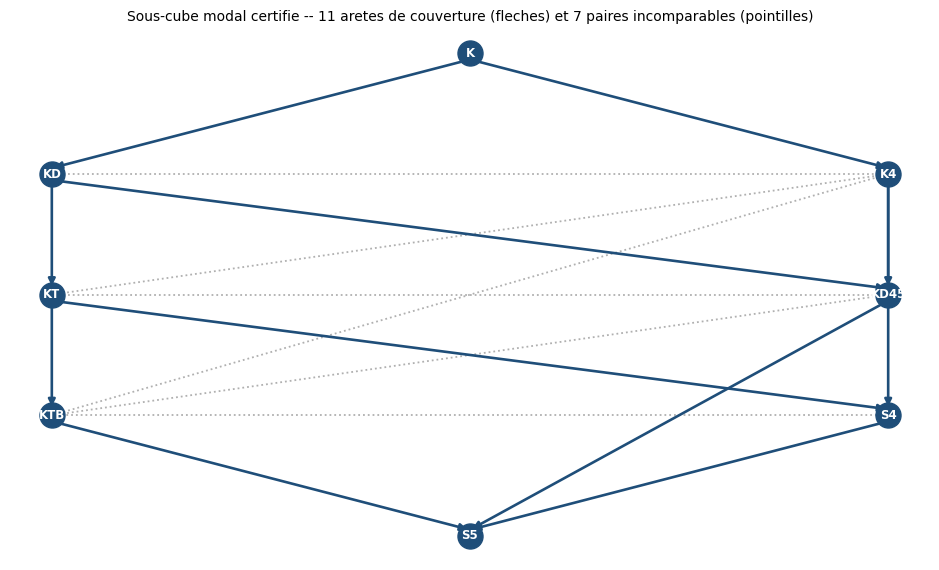

Rangs (plus long chemin depuis K) : K=0, KD=1, KT=2, KTB=3, K4=1, S4=3, KD45=2, S5=4
Aretes de couverture : 11 ; inclusions strictes : 21 ; deductions par transitivite : 10
Incomparables : K4 || KD, K4 || KT, K4 || KTB, KD45 || KT, KD45 || KTB, KD45 || S4, KTB || S4


In [5]:

# --- La carte : diagramme de Hasse des 11 aretes, et les 7 paires incomparables en pointilles ---
import matplotlib
import matplotlib.pyplot as plt

# Etagement : rang = plus long chemin depuis K. Un etagement par nombre d'axiomes serait faux --
# le profil de KD (1 schema) et celui de K4 (1 schema) ne sont pas comparables, et (KD, KT) relie
# deux systemes de meme taille de profil.
rang = {n: 0 for n in noms}
for _ in range(len(noms)):
    for a, b in covers_calc:
        rang[b] = max(rang[b], rang[a] + 1)

par_rang = {}
for n in noms:
    par_rang.setdefault(rang[n], []).append(n)
pos = {}
for r, groupe in sorted(par_rang.items()):
    for i, n in enumerate(groupe):
        pos[n] = ((i + 1) / (len(groupe) + 1), -r)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
for a, b in incomparables_calc:                      # les non-traits, dessines
    (x1, y1), (x2, y2) = pos[a], pos[b]
    ax.plot([x1, x2], [y1, y2], linestyle=":", color="#b0b0b0", linewidth=1.3, zorder=1)
for a, b in covers_calc:                             # les traits certifies
    (x1, y1), (x2, y2) = pos[a], pos[b]
    ax.annotate("", xy=(x2, y2 + 0.05), xytext=(x1, y1 - 0.05),
                arrowprops=dict(arrowstyle="-|>", color="#1f4e79", linewidth=1.9), zorder=2)
for n in noms:
    x, y = pos[n]
    ax.plot([x], [y], marker="o", markersize=18, color="#1f4e79", zorder=3)
    ax.text(x, y, n, color="white", ha="center", va="center", fontsize=8.5, zorder=4,
            fontweight="bold")
ax.set_axis_off()
ax.set_title("Sous-cube modal certifie -- 11 aretes de couverture (fleches) "
             "et 7 paires incomparables (pointilles)", fontsize=10)
fig.tight_layout()
plt.show()

print("Rangs (plus long chemin depuis K) :", ", ".join(f"{n}={rang[n]}" for n in noms))
print(f"Aretes de couverture : {len(covers_calc)} ; inclusions strictes : {len(strictes)} "
      f"; deductions par transitivite : {len(strictes) - len(covers_calc)}")
print("Incomparables :", ", ".join(f"{a} || {b}" for a, b in incomparables_calc))



### Lecture : lire la carte — un trait, deux significations, et une absence

La figure porte **trois** informations, et les confondre est l'erreur que la section précédente a
chiffrée :

1. **une flèche pleine** = une arête de couverture. `a → b` signifie `a` strictement plus faible que `b`,
   **et** aucun système du zoo entre les deux. Chaque flèche est un théorème du module ;
2. **un pointillé** = une paire incomparable. Le trait est là pour être **vu et barré** : c'est la
   réponse au réflexe qui relie deux nœuds voisins dans un dessin ;
3. **une absence de trait** entre deux nœuds reliés par un chemin = une inclusion **transitive**. `K` et
   `S4` ne sont pas reliés directement, et pourtant `K < S4` — par `K < K4 < S4`, ou par
   `K < KD < KT < S4`.

Deux flèches traversent un étage (`K4 → S4` et `KD45 → S5`) : ce n'est pas un défaut de dessin mais une
propriété de l'ordre — sa **hauteur** est 4 (la chaîne `K < KD < KT < KTB < S5` compte cinq éléments),
et aucun étagement ne peut faire tenir toutes les arêtes entre étages voisins.

Le compte final est le meilleur résumé du labo : **11 flèches + 10 transitives = 21 inclusions
strictes**, et **7 paires** qu'aucune flèche, dans aucun sens, ne peut relier. Sur les 28 paires du
cube, un quart échappe à toute échelle.



## Exercices

Les trois exercices reprennent les trois gestes du labo : **lire** les profils, **recalculer** l'ordre sur
une variante, **certifier** dans le lake. Les cellules de code ci-dessous sont des ébauches : elles
s'exécutent sans erreur et n'affichent que `Exercice a completer` tant qu'elles ne sont pas remplies.



## Exercice 1 : prédire l'ordre avant de le calculer

### Contexte

Le tableau des profils suffit à trancher toute question d'ordre — mais l'intuition se trompe
systématiquement sur les paires qui ne partagent pas d'axiome, parce qu'elle lit les **générateurs** au
lieu du **profil**.

### Objectifs

1. **Sans exécuter** : répondre sur le papier pour les trois couples `(KD, S4)`, `(KT, K4)` et
   `(KTB, KD45)` — inclusion dans un sens, inclusion réciproque, ou incomparabilité ?
2. Exécuter le contrôle : afficher, pour chaque couple, les profils des deux systèmes et les deux
   verdicts `le(a, b)` / `le(b, a)`, puis comparer à vos réponses.
3. Pour chaque écart éventuel, dire s'il vient des **générateurs** ou du **profil** — et citer la case
   qui décide (indice : le profil de `S4` contient un schéma que ses générateurs ne contiennent pas).

> **Indices :**
> - `profils` et `le` sont définis à la section 3 ; `gens` est le dictionnaire construit à la section 2 ;
> - la question « `KD` est-il plus faible que `S4` ? » se lit `{D} ⊆ {D, T, 4}` — c'est une inclusion
>   d'ensembles, pas une comparaison de tailles.


In [6]:

# --- Exercice 1 : predire puis verifier trois couples ---
# TODO etudiant
# Etape 1 : vos trois reponses sur papier -- (KD, S4), (KT, K4), (KTB, KD45)
# Etape 2 : pour chaque couple, afficher profil(a), profil(b), le(a, b) et le(b, a)
# Etape 3 : nommer le schema qui decide, et dire s'il vient des generateurs ou de la cloture
print("Exercice a completer")


Exercice a completer



## Exercice 2 : un neuvième système — `K5`

### Contexte

Le zoo s'arrête à huit systèmes **nommés**. Sur les cinq schémas `D, T, B, 4, 5`, il existe 32 profils ;
24 n'ont pas de nom d'usage. Ajoutez-en un au calcul : `K5`, de profil `{5}` — l'axiome d'euclidianité
seul, sans réflexivité, sans sérialté, sans transitivité.

### Objectifs

1. **Sans exécuter** : `K5` est-il comparable aux huit systèmes du zoo ? Auxquels, et dans quel sens ?
   (indice : `{5}` est inclus dans les profils qui **contiennent** `5` — lesquels ?)
2. Ajouter `K5` au dictionnaire `profils`, recalculer `le`, la liste des arêtes de couverture et celle
   des paires incomparables. De combien le nombre d'arêtes augmente-t-il, et quelles arêtes existantes
   disparaissent ?
3. Le module certifie `covers` **pour ses huit systèmes**. Que faudrait-il ajouter au lake pour que la
   carte à neuf systèmes soit certifiée elle aussi ? Répondre en deux phrases — c'est une question de
   méthode, pas de code.

> **Indices :**
> - `profils["K5"] = {"5"}` ;
> - `noms`, `couvre` et la boucle d'étagement de la section 4 se réutilisent tels quels — pensez à
>   reconstruire `paires` et `strictes` après l'ajout ;
> - pour la question 3 : que certifie **exactement** `mem_covers_iff`, et sur quel ensemble de systèmes ?


In [7]:

# --- Exercice 2 : K5 = profil {5} ---
# TODO etudiant
# Etape 1 : predire les systemes comparables a K5 (papier), et le sens de chaque inclusion
# Etape 2 : profils["K5"] = {"5"} ; recalculer aretes de couverture et paires incomparables
# Etape 3 : comparer le compte d'aretes a celui du zoo a huit systemes, et nommer la methode
#           qu'il faudrait suivre pour certifier cette carte a neuf systemes
print("Exercice a completer")


Exercice a completer



## Exercice 3 : deux certificats, et ce qu'ils coûtent

### Contexte

La section 3 a **calculé** l'ordre ; le module, lui, le **prouve**. Reste à relier les deux, et à mesurer
le prix des preuves.

### Objectifs

1. Par `run_lean`, faire vérifier par le noyau `strict_of_mem_covers` appliqué à une arête de votre choix,
   et `incomparable_of_mem` appliqué à une paire incomparable de votre choix. Les deux conclusions
   doivent apparaître dans la sortie.
2. Mesurer avec `#print axioms` les axiomes dont dépendent
   `FormalLogic.ModalZoo.strict_of_mem_covers` et `FormalLogic.ModalZoo.incomparable_of_mem`, et
   comparer au trio standard `[propext, Classical.choice, Quot.sound]`.
3. Le recalcul Python et le certificat Lean concluent la même chose sur les mêmes données : dire en une
   phrase ce que le certificat ajoute au recalcul.

> **Indices :**
> - le source Lean doit commencer par `import FormalLogic.ModalZoo` puis `open FormalLogic.ModalZoo` ;
> - `#check @strict_of_mem_covers` affiche son type ; le mettre à l'épreuve demande un `example` avec la
>   preuve d'appartenance à `covers` — `by decide` suffit sur ces listes finies ;
> - les listes `covers` et `incomparables` sont dans le namespace `FormalLogic.ModalZoo`.


In [8]:

# --- Exercice 3 : certifier une arete et une incomparabilite ---
# TODO etudiant
# Etape 1 : composer un source Lean qui #check les deux theoremes du module
# Etape 2 : ajouter un #print axioms sur chacun, et comparer au trio standard
# Etape 3 : executer via run_lean(...) et interpreter la sortie (conclusions + axiomes)
print("Exercice a completer")


Exercice a completer



## Conclusion — une carte, trois lectures

| Ce qui est lu | Par quel moteur | Ce que cela prouve |
|---|---|---|
| les trois listes (`nodes`, `covers`, `incomparables`) | le module, exécuté par `lake env lean` | les données du dessin viennent du lake épinglé — pas d'une recopie |
| l'ordre, reconstruit sur les seuls profils | Python, une trentaine de lignes | les 11 arêtes et les 7 incomparables sont reproductibles depuis les profils |
| les traits et les non-traits | le noyau Lean | 21 inclusions strictes et 7 incomparabilités, chacune par un théorème |

Le point à retenir n'est pas le nombre de systèmes, mais la **nature de la carte** : sur 28 paires, 7 ne
sont ordonnées dans aucun sens. Une carte mentale qui les rangerait sur une échelle serait fausse — et
c'est exactement ce que le comptage, puis le certificat, interdisent. Un ordre partiel n'est pas un ordre
total incomplet : c'est une structure d'une autre nature.

### Ce que ce labo ne couvre pas

- **la correspondance cadres ↔ axiomes dans le sens suffisant** : le module prouve `valid_D` … `valid_five`
  (une condition de cadre valide l'axiome) et exhibe quatre cadres finis pour les réfutations ; la
  **complétude** de Kripke pour ces huit systèmes n'y est pas — c'est un résultat d'une autre ampleur,
  hors du périmètre de cette tranche ;
- **le versant Java** : la syntaxe modale exécutée par Tweety est le sujet de
  [Tweety-3b](Tweety-3b-Modal-Lab-Lean.ipynb) ; ce labo-ci est certifiant de bout en bout, et l'absence
  de JVM y est un choix, pas une dégradation ;
- **les 24 profils sans nom** : le zoo est un *sous*-cube choisi pour ses noms d'usage, pas une
  énumération des 32 profils — l'exercice 2 en explore un.

### Références

- le module : [`FormalLogic/ModalZoo.lean`](../Lean/formal_logic_lean/FormalLogic/ModalZoo.lean) — [#17642](https://github.com/jsboige/CoursIA/pull/17642)
- l'EPIC : [#15066](https://github.com/jsboige/CoursIA/issues/15066) — Tranche G
- le labo modal côté exécution : [Tweety-3b-Modal-Lab-Lean](Tweety-3b-Modal-Lab-Lean.ipynb)
